## Introduction and Problem Statement 
## Objective
To predict whether a loan applicant will be approved based on applicant information and also whether an applicant is likely to default on a loan.

## Problem Statement
Financial institutions need reliable methods to evaluate loan applications. This project develops a classification model that predicts loan approval status using applicant demographic and financial information.

## Dataset Understanding and Description
## Important Variables 
| Variable        | Description               |
| --------------- | ------------------------- |
| Gender          | Applicant gender          |
| Married         | Marital status            |
| Education       | Educational qualification |
| ApplicantIncome | Applicant income          |
| LoanAmount      | Loan amount requested     |
| Credit_History  | Credit history record     |
| Loan_Status     | Target variable           |

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
# Load dataset
loan = pd.read_csv(r"C:\Users\UDDYBON\Downloads\loan_data.csv")

In [3]:
# Display dataset information 
loan.head()
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           10000 non-null  str    
 1   Gender                10000 non-null  str    
 2   Marital_Status        10000 non-null  str    
 3   Number_of_Dependents  10000 non-null  str    
 4   Education             10000 non-null  str    
 5   Loan_Status           10000 non-null  str    
 6   Annual_Income         9000 non-null   float64
 7   Credit_Score          8979 non-null   float64
 8   Loan_Amount           8987 non-null   float64
 9   Term                  10000 non-null  int64  
 10  Property_Area         10000 non-null  str    
 11  Loan_Approval         10000 non-null  str    
dtypes: float64(3), int64(1), str(8)
memory usage: 937.6 KB


## Data Cleaning and Preparation

In [4]:
# Check missing values 
loan.isnull().sum()

Customer_ID                0
Gender                     0
Marital_Status             0
Number_of_Dependents       0
Education                  0
Loan_Status                0
Annual_Income           1000
Credit_Score            1021
Loan_Amount             1013
Term                       0
Property_Area              0
Loan_Approval              0
dtype: int64

In [5]:
# Fill missing values 
loan.fillna(loan.mode().iloc[0],
            inplace=True)

,Customer_ID,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,LP216038,Female,No,2,Graduate,No,4809.0,3329.0,3650.0,180,Rural,Yes
1,LP288956,Female,Yes,1,Graduate,No,3358.0,1303.0,6680.0,360,Rural,No
2,LP153364,Female,Yes,1,Graduate,No,9873.0,1649.0,261.0,360,Semiurban,No
3,LP945891,Male,No,0,Graduate,Yes,11665.0,4378.0,8366.0,360,Rural,Yes
4,LP425056,Female,No,1,Graduate,No,5890.0,1523.0,8741.0,180,Urban,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,LP693571,Male,Yes,3+,Graduate,Yes,8998.0,2137.0,2487.0,360,Semiurban,Yes
9996,LP193182,Female,No,1,Graduate,Yes,7186.0,1303.0,5380.0,360,Rural,Yes
9997,LP668937,Male,No,0,Not Graduate,No,2778.0,678.0,2794.0,180,Rural,Yes
9998,LP447580,Male,No,3+,Graduate,Yes,4746.0,1172.0,261.0,180,Semiurban,No


In [7]:
# Encode categorical variables 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in loan.select_dtypes(include='object'):
    loan[col] = le.fit_transform(loan[col].astype(str))

## Exploratory Data Analysis

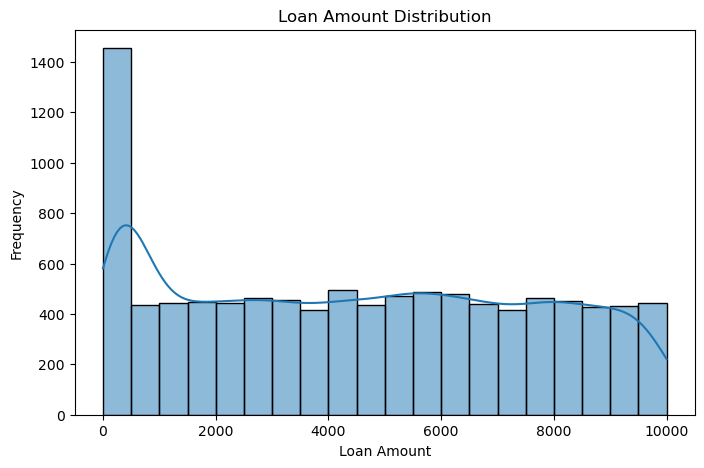

In [8]:
# Loan Amount Distribution
plt.figure(figsize=(8,5))

sns.histplot(loan["Loan_Amount"],
            kde=True) 

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

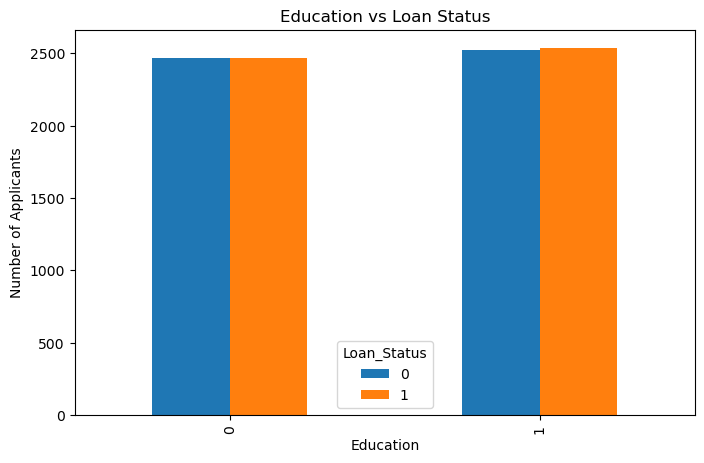

In [9]:
# Education level compared with loan approval
pd.crosstab(loan['Education'],
            loan['Loan_Status']).plot(kind='bar',
                                       figsize=(8,5))

plt.title("Education vs Loan Status")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")
plt.show()

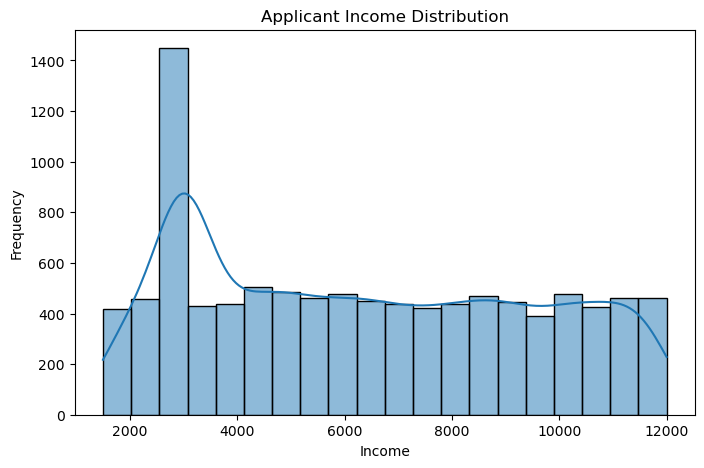

In [10]:
# Distribution of Applicant Income
plt.figure(figsize=(8,5))

sns.histplot(loan['Annual_Income'],
             kde=True)

plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

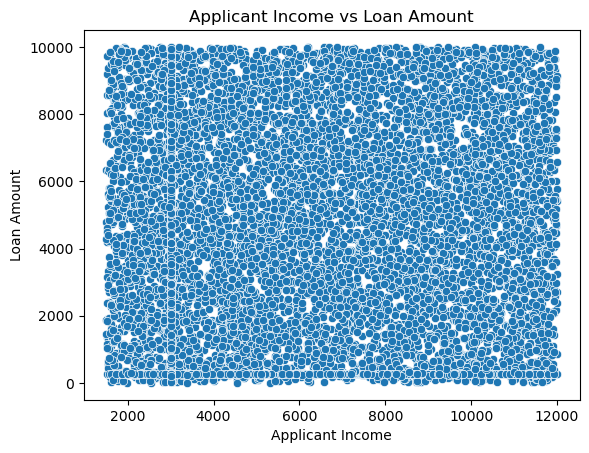

In [11]:
# Relationship between Income and Loan Amount
sns.scatterplot(data=loan,
                x='Annual_Income',
                y='Loan_Amount')

plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.show()

## Model Training and Testing

In [12]:
# Separate predictors and Target Variable
X = loan.drop("Loan_Status", axis=1)
y = loan["Loan_Status"]

In [13]:
# Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

## Logistic Regression

In [14]:
# Import model
from sklearn.linear_model import LogisticRegression

In [15]:
# Create model
model = LogisticRegression(max_iter=5000)

In [16]:
# Train model 
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Predictions

In [17]:
# Predict Loan Approval 
predictions = model.predict(X_test)

## Evaluation Metrics

## Accuracy

In [18]:
# Calculate accuracy 
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, 
                          predictions)

print("Accuracy:", accuracy)

Accuracy: 0.5215


## Confusion Matrix 

In [19]:
# Generate confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, 
                      predictions)

print(cm)

[[543 463]
 [494 500]]


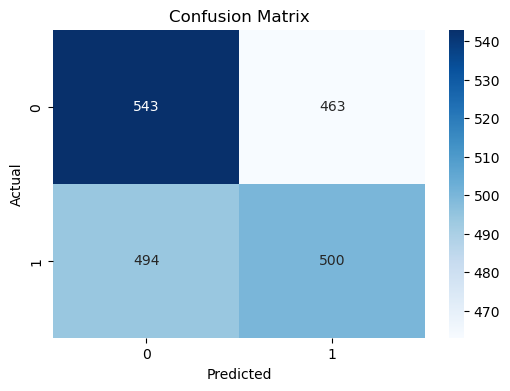

In [20]:
# Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Conclusion and Key Insights
## Conclusion
The loan dataset was analyzed to understand applicant characteristics and develop a predictive model for loan approval decisions. Exploratory analysis highlighted important relationships among income, education level, and loan amounts.

## Key Insights
1) Loan Amount Distribution
* Loan amounts appear unevenly distributed.
* Most applicants requested loans within a moderate range.
* Relatively few applicants requested extremely high loan amounts.

2) Applicant Income Distribution
* Applicant income is positively skewed.
* Most applicants fall within lower-to-middle income categories.
* A few applicants have substantially higher incomes.

3) Education and Loan Approval
* The Education vs Loan Status chart suggests that education level may influence approval outcomes.
* Graduates appear to constitute a larger proportion of approved applicants.

4) Income and Loan Amount
* The scatter plot indicates that loan amount alone is not perfectly explained by applicant income.
* Individuals with similar income levels often request different loan amounts.

5) Model Performance
* The confusion matrix shows that the model correctly classified a substantial number of applicants.
* The classification model demonstrates reasonable predictive capability for loan approval decisions.

## Overall Observation 
Income, education level, and credit-related variables appear to play an important role in loan decisions.